In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Alka Patel\Downloads\Sales Data.csv")

In [3]:
df.head()

,Date,Total_QTY
0,01-04-2016,295304.80
1,01-05-2016,389404.85
2,01-06-2016,454429.85
3,01-07-2016,302825.05
4,01-08-2016,302694.25


In [4]:
df.value_counts()

Date        Total_QTY
01-01-2017  364416.50    1
01-01-2018  354225.00    1
01-01-2019  395354.00    1
01-01-2020  371332.00    1
01-01-2021  381465.00    1
                        ..
01-12-2021  319335.00    1
01-12-2022  390593.00    1
01-12-2023  364905.00    1
01-12-2024  409358.03    1
01-12-2025  452421.20    1
Name: count, Length: 118, dtype: int64

In [5]:
# Convert date correctly
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Sort and set index
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Monthly frequency
df = df.asfreq('MS')

print(df.head())

            Total_QTY
Date                 
2016-04-01  295304.80
2016-05-01  389404.85
2016-06-01  454429.85
2016-07-01  302825.05
2016-08-01  302694.25


In [6]:
df.head()

,Total_QTY
Date,
2016-04-01,295304.80
2016-05-01,389404.85
2016-06-01,454429.85
2016-07-01,302825.05
2016-08-01,302694.25


In [7]:
df.isnull().sum()

Total_QTY    0
dtype: int64

In [8]:
df['covid_dummy'] = 0
df.loc['2020-04-01':'2021-03-01', 'covid_dummy'] = 1

In [9]:
df.head()

,Total_QTY,covid_dummy
Date,,
2016-04-01,295304.80,0
2016-05-01,389404.85,0
2016-06-01,454429.85,0
2016-07-01,302825.05,0
2016-08-01,302694.25,0


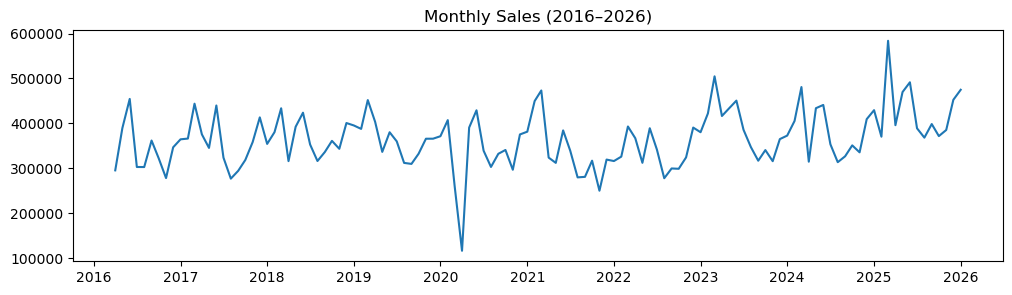

In [10]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(df['Total_QTY'])
plt.title("Monthly Sales (2016–2026)")
plt.show()

#Strong long-term upward trend
#Strong annual seasonality (period = 12)

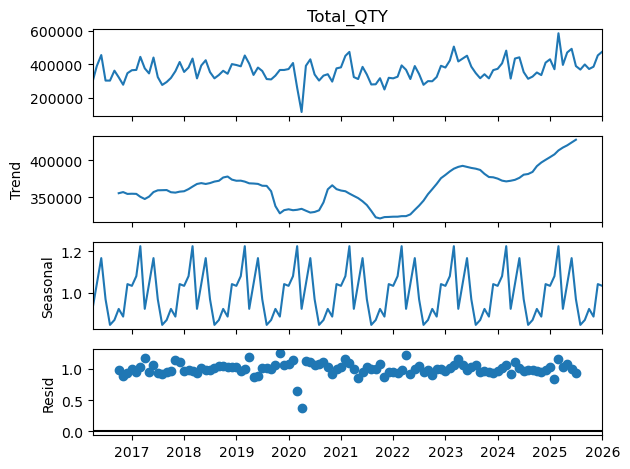

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Total_QTY'], model='multiplicative', period=12)
result.plot()
plt.show()

# Multiplicative will be good to proceed with.

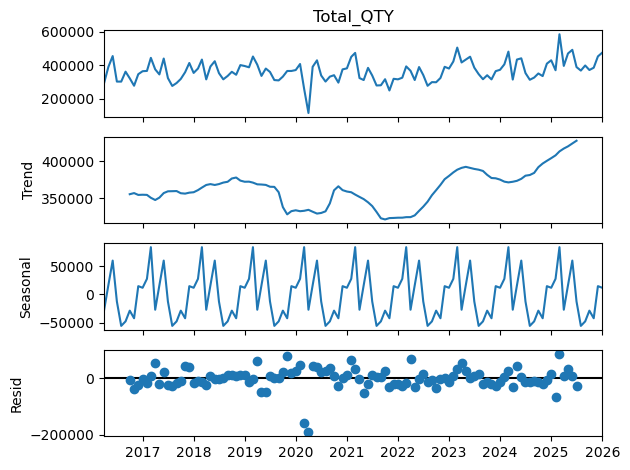

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Total_QTY'], model='additive', period=12)
result.plot()
plt.show()

In [13]:
#| Component        | Conclusion                 |
#| ---------------- | -------------------------- |
#| Trend            | Strong upward              |
#| Seasonality      | Strong, stable (12 months) |
#| Structural Break | Yes (2020)                 |
#| Residual         | Mostly white noise         |
#| Stationary?      | ❌ No                       |


ADF (Augmented Dickey-Fuller) tests:

H₀ (Null Hypothesis):

Series is non-stationary

H₁ (Alternative):

Series is stationary

So:

p-value > 0.05 → Non-stationary ❌

p-value < 0.05 → Stationary ✅

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Total_QTY'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -0.5111500058645997
p-value: 0.8898222200781611
Critical Values: {'1%': np.float64(-3.4936021509366793), '5%': np.float64(-2.8892174239808703), '10%': np.float64(-2.58153320754717)}


In [15]:
df['diff1'] = df['Total_QTY'].diff()

result_diff1 = adfuller(df['diff1'].dropna())

print("ADF Statistic:", result_diff1[0])
print("p-value:", result_diff1[1])

ADF Statistic: -3.730434732370498
p-value: 0.0037048677807254102


In [16]:
df['seasonal_diff'] = df['Total_QTY'].diff(12)
adfuller(df['seasonal_diff'].dropna())

(np.float64(-3.7886452616602364),
 np.float64(0.003025648888794865),
 12,
 93,
 {'1%': np.float64(-3.502704609582561),
  '5%': np.float64(-2.8931578098779522),
  '10%': np.float64(-2.583636712914788)},
 np.float64(2268.270735226137))

In [17]:
df['combined_diff'] = df['Total_QTY'].diff().diff(12)
adfuller(df['combined_diff'].dropna())

(np.float64(-4.409877353541803),
 np.float64(0.0002851103018995628),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(2254.018012612826))

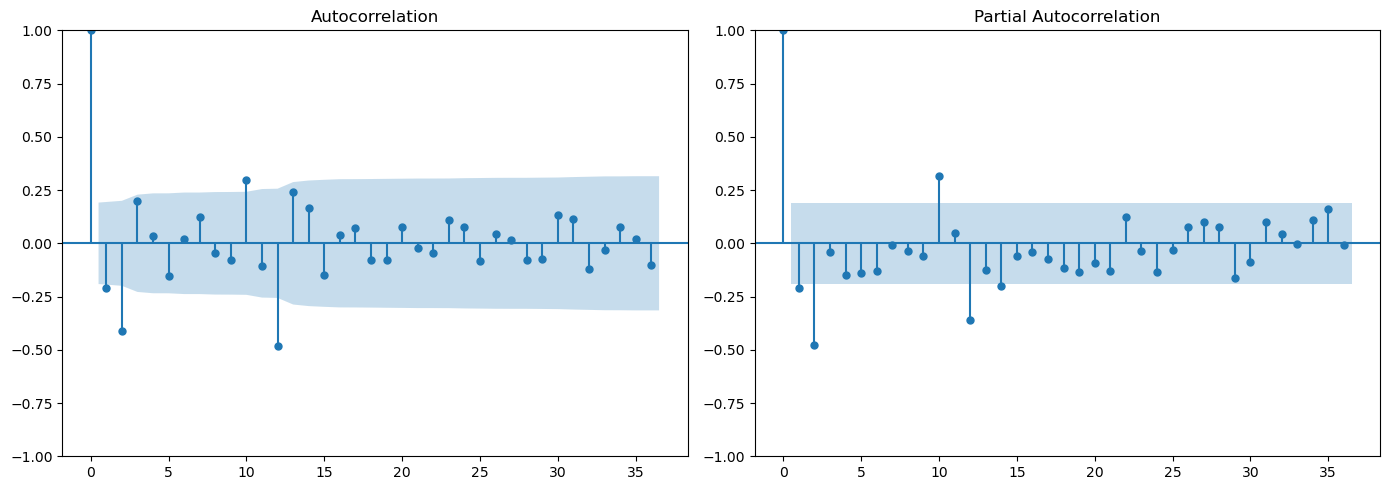

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df['combined_diff'].dropna()

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plot_acf(series, lags=36, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(series, lags=36, ax=plt.gca())

plt.tight_layout()
plt.show()

#here q=1 or 2 from acf plot
# p=1
# Q=1
# P=1

In [19]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 106
Test size: 12


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['Total_QTY'],
                order=(0,1,1),
                seasonal_order=(0,1,1,12),
                exog=train[['covid_dummy']])

results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Total_QTY   No. Observations:                  106
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1154.432
Date:                            Wed, 17 Jun 2026   AIC                           2316.864
Time:                                    22:24:28   BIC                           2326.995
Sample:                                04-01-2016   HQIC                          2320.955
                                     - 01-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
covid_dummy  6547.1667   2.94e+04      0.222      0.824   -5.12e+04    6.43e+04
ma.L1          -0.2650      0.09

In [21]:

forecast = results.forecast(steps=12,
                            exog=test[['covid_dummy']])

In [22]:
forecast

2025-02-01    453673.181772
2025-03-01    505754.902446
2025-04-01    401684.997671
2025-05-01    453860.687222
2025-06-01    487979.335618
2025-07-01    418701.462050
2025-08-01    374786.777488
2025-09-01    379807.805511
2025-10-01    398705.610830
2025-11-01    383401.812071
2025-12-01    444847.355066
2026-01-01    450575.075897
Freq: MS, Name: predicted_mean, dtype: float64

In [23]:
mape = np.mean(np.abs((test['Total_QTY'] - forecast) / test['Total_QTY']))
print("MAPE:", mape)

MAPE: 0.05840881827201553


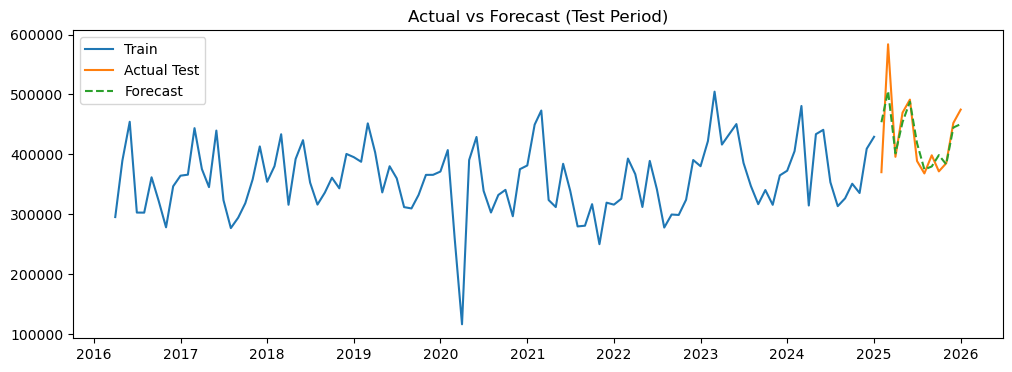

In [24]:
plt.figure(figsize=(12,4))

plt.plot(train.index, train['Total_QTY'], label='Train')
plt.plot(test.index, test['Total_QTY'], label='Actual Test')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')

plt.legend()
plt.title('Actual vs Forecast (Test Period)')
plt.show()

#model validation
# 1️⃣ Residual Diagnostics (Most Important)
A good time-series model must leave:

Residuals = White Noise

That means:

No autocorrelation

No pattern

Mean ≈ 0

Constant variance (ideally)


# 2️⃣ Overfitting Check

# 3️⃣ Stability of Forecast

# 4️⃣ Compare With Naive Model(Benchmark Test)


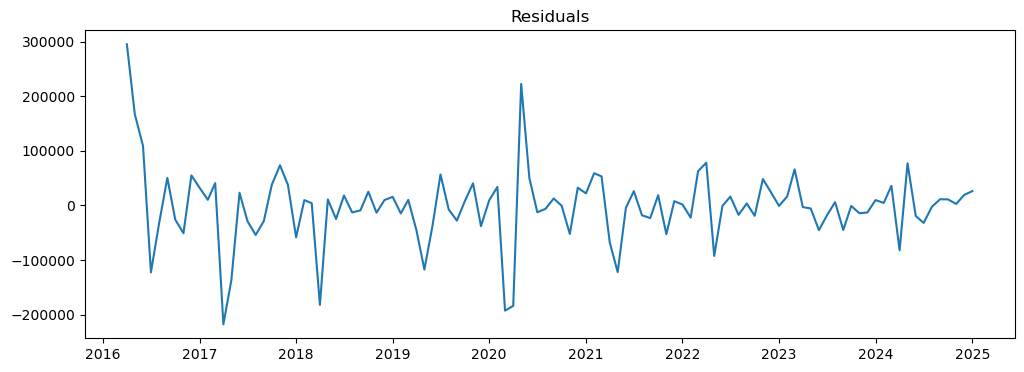

In [25]:
#🔹 Check Residual Plot

residuals = results.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

#You should NOT see:

#Trend

#Seasonality

#Pattern

#If pattern exists → model missing structure.

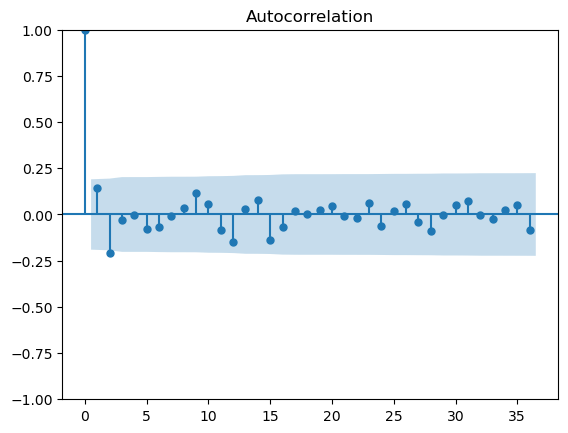

In [26]:
#🔹 Check Residual ACF

plot_acf(residuals.dropna(), lags=36)
plt.show()


#If spikes outside confidence band → model incomplete.

#If most spikes inside band → good.

In [27]:
#🔹 Ljung-Box Test(from model)
#Since p > 0.05:

#✅ Residuals are not autocorrelated
#This is strong evidence of good fit.

In [28]:
#✅ 2️⃣ Overfitting Check
#✅ 3️⃣ Stability of Forecast

In [29]:
#Seasonal Naive Forecast
#Meaning:
#Next year same month = last year same month.
#If your SARIMA beats naive model significantly → real improvement

In [30]:
# Seasonal Naive Forecast (lag 12)
naive_forecast = train['Total_QTY'].iloc[-12:].values

# Align with test index
naive_forecast = pd.Series(naive_forecast, index=test.index) 

In [31]:
naive_forecast

Date
2025-02-01    405309.55
2025-03-01    480804.10
2025-04-01    314631.15
2025-05-01    433726.98
2025-06-01    441003.95
2025-07-01    353430.85
2025-08-01    313524.20
2025-09-01    326615.30
2025-10-01    350967.12
2025-11-01    335447.08
2025-12-01    409358.03
2026-01-01    429350.90
Freq: MS, dtype: float64

In [32]:
#Calculate Errors for Naive Model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(test['Total_QTY'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['Total_QTY'], naive_forecast))
mape_naive = np.mean(np.abs((test['Total_QTY'] - naive_forecast) / test['Total_QTY'])) * 100

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive MAPE:", mape_naive)

Naive MAE: 52229.435
Naive RMSE: 56663.60580395011
Naive MAPE: 12.095302089135028


📊 What This Means

Your model reduced error by:

12.09
−
5.84
12.09
≈
52
%
12.09
12.09−5.84
	​

≈52%

👉 More than 50% improvement over baseline.

That is NOT small.
That is significant predictive gain.

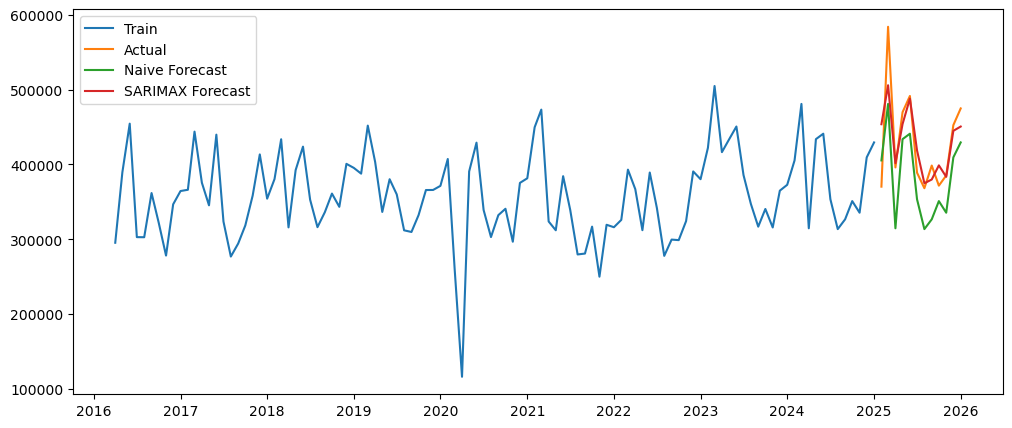

In [33]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Total_QTY'], label='Train')
plt.plot(test.index, test['Total_QTY'], label='Actual')
plt.plot(test.index, naive_forecast, label='Naive Forecast')
plt.plot(test.index, forecast, label='SARIMAX Forecast')
plt.legend()
plt.show()

In [34]:
#✅ STEP 1 — Remove COVID Dummy

model_final = SARIMAX(
    train['Total_QTY'],
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_final = model_final.fit()
print(results_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Total_QTY   No. Observations:                  106
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1154.546
Date:                            Wed, 17 Jun 2026   AIC                           2315.092
Time:                                    22:24:35   BIC                           2322.690
Sample:                                04-01-2016   HQIC                          2318.160
                                     - 01-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2611      0.081     -3.231      0.001      -0.419      -0.103
ma.S.L12      -0.6770      0.105   

In [35]:
print("Old AIC:", results.aic)        # with dummy
print("New AIC:", results_final.aic)  # without dummy

Old AIC: 2316.864243352003
New AIC: 2315.091879494667


In [36]:
forecast_final = results_final.forecast(steps=len(test))

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_final = mean_absolute_error(test['Total_QTY'], forecast_final)
rmse_final = np.sqrt(mean_squared_error(test['Total_QTY'], forecast_final))
mape_final = np.mean(np.abs((test['Total_QTY'] - forecast_final) / test['Total_QTY'])) * 100

print("Final MAE:", mae_final)
print("Final RMSE:", rmse_final)
print("Final MAPE:", mape_final)

Final MAE: 25204.579411898536
Final RMSE: 36531.572967227105
Final MAPE: 5.844326119354905


In [37]:
model_locked = SARIMAX(
    df['Total_QTY'],
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_locked = model_locked.fit()

In [38]:
future_forecast = results_locked.get_forecast(steps=12)

forecast_values = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()

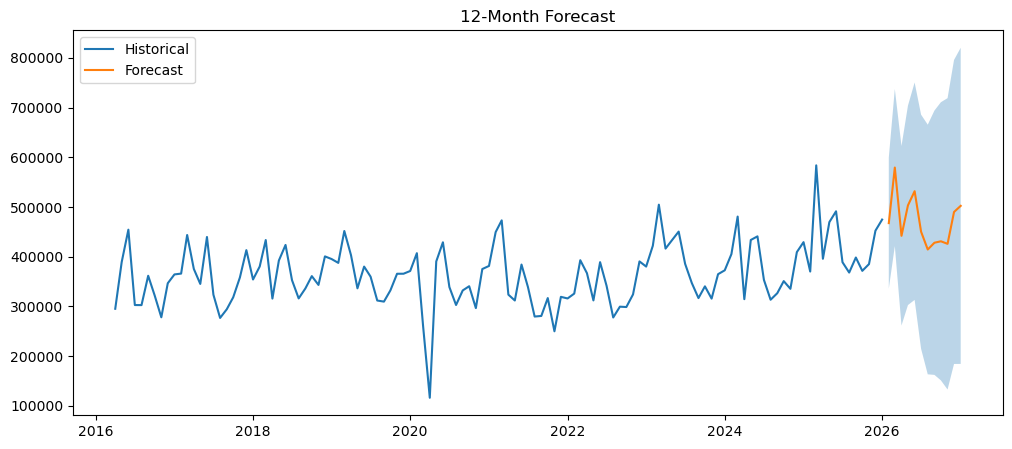

In [39]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Total_QTY'], label='Historical')
plt.plot(forecast_values.index, forecast_values, label='Forecast')

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("12-Month Forecast")
plt.show()

In [40]:
print(forecast_values)

2026-02-01    467650.975361
2026-03-01    579450.639147
2026-04-01    442159.766292
2026-05-01    503349.662952
2026-06-01    531872.855633
2026-07-01    450352.168807
2026-08-01    414564.168051
2026-09-01    428192.240681
2026-10-01    431080.999377
2026-11-01    425960.129007
2026-12-01    490070.269155
2027-01-01    502400.211847
Freq: MS, Name: predicted_mean, dtype: float64


In [41]:
#✅ MODEL 1 — Holt-Winters (Triple Exponential Smoothing)


from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal='mul',   # try 'add' also later
    seasonal_periods=12
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(steps=len(test))

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_hw = mean_absolute_error(test['Total_QTY'], hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test['Total_QTY'], hw_forecast))
mape_hw = np.mean(np.abs((test['Total_QTY'] - hw_forecast) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw)

Holt-Winters MAPE: 11.956420664873063


In [43]:
##✅ MODEL 2 — Holt’s Linear Trend (No Seasonality)
hw_linear = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal=None
)

fit_linear = hw_linear.fit()
forecast_linear = fit_linear.forecast(len(test))

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

linear_hw = mean_absolute_error(test['Total_QTY'], forecast_linear)
linear_hw = np.sqrt(mean_squared_error(test['Total_QTY'], forecast_linear))
linear_hw = np.mean(np.abs((test['Total_QTY'] - forecast_linear) / test['Total_QTY'])) * 100

print("Holt-Winters-linear MAPE:", linear_hw)

Holt-Winters-linear MAPE: 13.642379649748298


In [45]:
#✅ MODEL 3 — Simple Exponential Smoothing (Baseline Smooth)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train['Total_QTY'])
ses_fit = ses_model.fit()
ses_forecast = ses_fit.forecast(len(test))

In [46]:
ses_hw = mean_absolute_error(test['Total_QTY'], ses_forecast)
ses_hw = np.sqrt(mean_squared_error(test['Total_QTY'], ses_forecast))
ses_hw = np.mean(np.abs((test['Total_QTY'] - ses_forecast) / test['Total_QTY'])) * 100

print("Holt-Winters simple MAPE:", ses_hw)

Holt-Winters simple MAPE: 11.267295985753979


In [47]:
print("SARIMA MAPE:", 5.84)
print("Naive MAPE:", 12.09)
print("Holt-Winters MAPE:", mape_hw)
print("Holt Linear MAPE:", linear_hw)
print("SES MAPE:", ses_hw)

SARIMA MAPE: 5.84
Naive MAPE: 12.09
Holt-Winters MAPE: 11.956420664873063
Holt Linear MAPE: 13.642379649748298
SES MAPE: 11.267295985753979


In [48]:
###### try with other parameters too

hw_model1 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal='add',   # try 'add' also later
    seasonal_periods=12
)

hw_fit1 = hw_model1.fit()

hw_forecast1 = hw_fit1.forecast(steps=len(test))

mape_hw1 = np.mean(np.abs((test['Total_QTY'] - hw_forecast1) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw1)

Holt-Winters MAPE: 10.97815549020243


In [49]:
hw_model2 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='mul',
    seasonal='add',   # try 'add' also later
    seasonal_periods=12
)

hw_fit2 = hw_model2.fit()

hw_forecast2 = hw_fit2.forecast(steps=len(test))

mape_hw2 = np.mean(np.abs((test['Total_QTY'] - hw_forecast2) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw2)

Holt-Winters MAPE: 11.785732986602447


In [50]:
hw_model3 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='mul',
    seasonal='mul',   # try 'add' also later
    seasonal_periods=12
)

hw_fit3 = hw_model3.fit()

hw_forecast3 = hw_fit3.forecast(steps=len(test))

mape_hw3 = np.mean(np.abs((test['Total_QTY'] - hw_forecast3) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw3)

Holt-Winters MAPE: 11.354262506325037


In [51]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [52]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train['Total_QTY'],
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.79 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2628.031, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2612.111, Time=2.68 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2603.190, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3016.559, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2607.687, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=2605.074, Time=0.70 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=2599.178, Time=0.31 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=2601.115, Time=0.78 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=2615.136, Time=0.25 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=2605.333, Time=0.48 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=2597.003, Time=0.36 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=2601.532, Time=0.18 sec
 ARIMA(0,0,2)(1,0,2)[12] intercept   : AIC=2598.973, Time=0.86 sec
 ARIMA(0,0,2)(1,0,1)[12]

In [53]:
##-------------------------Step 1 — Rolling One-Step Ahead Forecast

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

rolling_errors = []

# start after enough data (at least 2 years)
start_point = 60  

for i in range(start_point, len(df)-1):
    
    train_roll = df['Total_QTY'][:i]
    test_roll = df['Total_QTY'][i:i+1]

    model_roll = SARIMAX(
        train_roll,
        order=(0,1,1),
        seasonal_order=(0,1,1,12)
    )
    
    results_roll = model_roll.fit(disp=False)
    forecast_roll = results_roll.forecast(steps=1)

    error = mean_absolute_percentage_error(test_roll, forecast_roll)
    rolling_errors.append(error)

rolling_mape = np.mean(rolling_errors) * 100
print("Rolling MAPE:", rolling_mape)

D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Rolling MAPE: 8.542391126920421


In [54]:
## model_tuned SARIMA

model_tuned = SARIMAX(
    train['Total_QTY'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results_tuned = model_tuned.fit()

forecast_tuned = results_tuned.forecast(len(test))

mape_tuned = np.mean(np.abs((test['Total_QTY'] - forecast_tuned) / test['Total_QTY'])) * 100
print("Tuned SARIMA MAPE:", mape_tuned)

Tuned SARIMA MAPE: 6.396200553246058


In [55]:
##A2 — Log Transformation (Very Powerful)

train_log = np.log(train['Total_QTY'])
test_log = np.log(test['Total_QTY'])

model_log = SARIMAX(
    train_log,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_log = model_log.fit()
forecast_log = results_log.forecast(len(test))

# Convert back
forecast_original = np.exp(forecast_log)

mape_log = np.mean(np.abs((test['Total_QTY'] - forecast_original) / test['Total_QTY'])) * 100
print("Log SARIMA MAPE:", mape_log)

Log SARIMA MAPE: 11.394083996278475


In [56]:
#A3 — Box-Cox Transformation

from scipy.stats import boxcox

train_boxcox, lam = boxcox(train['Total_QTY'])

model_box = SARIMAX(
    train_boxcox,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_box = model_box.fit()
forecast_box = results_box.forecast(len(test))

# Inverse transform
forecast_original = np.power(forecast_box * lam + 1, 1/lam)

mape_box = np.mean(np.abs((test['Total_QTY'] - forecast_original) / test['Total_QTY'])) * 100
print("BoxCox SARIMA MAPE:", mape_box)

BoxCox SARIMA MAPE: 6.210239914018842


In [57]:
####Prophet Models
from prophet import Prophet

df_prophet = pd.DataFrame({
    'ds': df.index,
    'y': df['Total_QTY']
})

Importing plotly failed. Interactive plots will not work.


In [58]:
df_prophet

,ds,y
Date,,
2016-04-01,2016-04-01,295304.80
2016-05-01,2016-05-01,389404.85
2016-06-01,2016-06-01,454429.85
2016-07-01,2016-07-01,302825.05
2016-08-01,2016-08-01,302694.25
...,...,...
2025-09-01,2025-09-01,398459.60
2025-10-01,2025-10-01,371623.74
2025-11-01,2025-11-01,385197.75


In [59]:
#pip install prophet

In [60]:
from prophet import Prophet

# Train-test split (same split as SARIMA)
train_prophet = df_prophet.iloc[:len(train)]
test_prophet = df_prophet.iloc[len(train):]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(
    periods=len(test),
    freq='MS'   # Month Start (important!)
)

forecast_prophet = model_prophet.predict(future)


22:25:35 - cmdstanpy - INFO - Chain [1] start processing
22:25:38 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
forecast_values = forecast_prophet['yhat'][-len(test):].values

mape_prophet = np.mean(
    np.abs((test['Total_QTY'].values - forecast_values)
           / test['Total_QTY'].values)
) * 100

print("Prophet MAPE:", mape_prophet)

Prophet MAPE: 12.68747756301494
